<a href="https://colab.research.google.com/github/Fu-Pei-Yin/Deep-Generative-Mode/blob/week7/%E6%99%82%E9%96%93%E5%BA%8F%E5%88%97.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
"""
利用 LSTM 與 Transformer 預測股價時間序列
作業完整實作程式碼
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

# 設定隨機種子
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

# ==================== 1. 資料準備 ====================

def download_stock_data(ticker='2330.TW', start='2020-01-01', end='2024-12-31'):
    """下載股價資料"""
    print(f"下載 {ticker} 資料...")
    data = yf.download(ticker, start=start, end=end)
    return data

def calculate_technical_indicators(df):
    """計算技術指標"""
    df = df.copy()

    # 趨勢型指標
    df['SMA_5'] = df['Close'].rolling(window=5).mean()
    df['SMA_20'] = df['Close'].rolling(window=20).mean()
    df['EMA_12'] = df['Close'].ewm(span=12, adjust=False).mean()
    df['EMA_26'] = df['Close'].ewm(span=26, adjust=False).mean()

    # 震盪型指標
    # RSI
    delta = df['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    df['RSI_14'] = 100 - (100 / (1 + rs))

    # MACD
    df['MACD'] = df['EMA_12'] - df['EMA_26']
    df['MACD_SIGNAL'] = df['MACD'].ewm(span=9, adjust=False).mean()
    df['MACD_HIST'] = df['MACD'] - df['MACD_SIGNAL']

    # 波動型指標
    # Bollinger Bands
    bb_middle = df['Close'].rolling(window=20).mean()
    bb_std = df['Close'].rolling(window=20).std()
    df['BB_MIDDLE'] = bb_middle
    df['BB_UPPER'] = bb_middle + (bb_std * 2)
    df['BB_LOWER'] = bb_middle - (bb_std * 2)
    df['BB_WIDTH'] = df['BB_UPPER'] - df['BB_LOWER']

    # ATR (Average True Range)
    high_low = df['High'] - df['Low']
    high_close = (df['High'] - df['Close'].shift()).abs()
    low_close = (df['Low'] - df['Close'].shift()).abs()
    ranges = pd.concat([high_low, high_close, low_close], axis=1)
    true_range = ranges.max(axis=1)
    df['ATR_14'] = true_range.rolling(window=14).mean()

    # 量能型指標
    # OBV (On-Balance Volume)
    obv = (np.sign(df['Close'].diff()) * df['Volume']).fillna(0).cumsum()
    df['OBV'] = obv

    # Volume SMA
    df['Volume_SMA_20'] = df['Volume'].rolling(window=20).mean()

    # 移除 NaN
    df = df.dropna()

    return df

def prepare_features_and_target(df):
    """準備特徵和目標變數"""
    df = df.copy()

    # 計算 log return 作為目標
    df['logret'] = np.log(df['Close']).diff()

    # 選擇特徵
    feature_cols = ['Open', 'High', 'Low', 'Close', 'Volume',
                    'SMA_5', 'SMA_20', 'RSI_14', 'MACD', 'MACD_SIGNAL', 'MACD_HIST',
                    'BB_WIDTH', 'ATR_14', 'OBV', 'Volume_SMA_20']

    df = df.dropna()

    return df, feature_cols

def create_sequences(data, features, target, lookback=30):
    """創建時間序列樣本"""
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i, :])
        y.append(target[i])
    return np.array(X), np.array(y)

# ==================== 2. Dataset 類別 ====================

class StockDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# ==================== 3. 模型定義 ====================

class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, dropout=0.1):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True, dropout=dropout)
        self.layer_norm = nn.LayerNorm(hidden_dim)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # x shape: (batch, seq_len, input_dim)
        lstm_out, (h_n, c_n) = self.lstm(x)
        # 取最後一個時間步
        last_hidden = lstm_out[:, -1, :]
        normalized = self.layer_norm(last_hidden)
        output = self.fc(normalized)
        return output.squeeze(-1)

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x shape: (batch, seq_len, d_model)
        x = x + self.pe[:, :x.size(1), :]
        return x

class TransformerModel(nn.Module):
    def __init__(self, input_dim, d_model=128, nhead=8, num_layers=2,
                 dim_feedforward=256, dropout=0.1):
        super(TransformerModel, self).__init__()

        # Input projection
        self.input_projection = nn.Linear(input_dim, d_model)

        # Positional encoding
        self.pos_encoder = PositionalEncoding(d_model)

        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Output layer
        self.fc = nn.Linear(d_model, 1)

        self.d_model = d_model
        self.attention_weights = None

    def forward(self, x):
        # x shape: (batch, seq_len, input_dim)
        x = self.input_projection(x)
        x = self.pos_encoder(x)

        # 為了獲取注意力權重，我們需要手動處理最後一層
        for i, layer in enumerate(self.transformer_encoder.layers):
            if i == len(self.transformer_encoder.layers) - 1:
                # 最後一層，保存注意力權重
                attn_output, attn_weights = layer.self_attn(x, x, x, average_attn_weights=False)
                self.attention_weights = attn_weights.detach()
                x = layer.self_attn(x, x, x)[0]
                x = layer.norm1(x + layer.dropout1(attn_output))
                x = layer.norm2(x + layer._ff_block(x))
            else:
                x = layer(x)

        # Mean pooling
        x = x.mean(dim=1)

        # Output
        output = self.fc(x)
        return output.squeeze(-1)

# ==================== 4. 訓練函數 ====================

def train_epoch(model, train_loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader)

def validate(model, val_loader, criterion, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            total_loss += loss.item()

    return total_loss / len(val_loader)

def predict(model, test_loader, device):
    model.eval()
    predictions = []
    actuals = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)
            predictions.extend(outputs.cpu().numpy())
            actuals.extend(y_batch.numpy())

    return np.array(predictions), np.array(actuals)

# ==================== 5. 主程式 ====================

def main():
    # 設定
    TICKER = '2330.TW'
    LOOKBACK = 30
    BATCH_SIZE = 64
    EPOCHS = 30

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"使用設備: {device}")

    # 1. 下載和準備資料
    raw_data = download_stock_data(TICKER)
    data_with_indicators = calculate_technical_indicators(raw_data)
    df, feature_cols = prepare_features_and_target(data_with_indicators)

    print(f"\n資料形狀: {df.shape}")
    print(f"特徵數量: {len(feature_cols)}")

    # 2. 時間序列切分 (8:1:1)
    n = len(df)
    train_size = int(n * 0.8)
    val_size = int(n * 0.1)

    train_df = df.iloc[:train_size]
    val_df = df.iloc[train_size:train_size+val_size]
    test_df = df.iloc[train_size+val_size:]

    print(f"\n訓練集: {len(train_df)}, 驗證集: {len(val_df)}, 測試集: {len(test_df)}")

    # 3. 標準化（只用訓練集 fit）
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()

    train_X = scaler_X.fit_transform(train_df[feature_cols])
    train_y = scaler_y.fit_transform(train_df[['logret']])

    val_X = scaler_X.transform(val_df[feature_cols])
    val_y = scaler_y.transform(val_df[['logret']])

    test_X = scaler_X.transform(test_df[feature_cols])
    test_y = scaler_y.transform(test_df[['logret']])

    # 保存 Close 價格用於後續轉換（保存完整的 DataFrame Close 列）
    test_close_full = test_df['Close'].values

    print(f"Test Close 價格數量: {len(test_close_full)}")
    print(f"預期序列數量 (test_size - lookback): {len(test_df) - LOOKBACK}")

    # 4. 創建序列
    X_train, y_train = create_sequences(train_X, feature_cols, train_y.flatten(), LOOKBACK)
    X_val, y_val = create_sequences(val_X, feature_cols, val_y.flatten(), LOOKBACK)
    X_test, y_test = create_sequences(test_X, feature_cols, test_y.flatten(), LOOKBACK)

    print(f"\nX_train shape: {X_train.shape}")
    print(f"y_train shape: {y_train.shape}")

    # 5. 創建 DataLoader
    train_dataset = StockDataset(X_train, y_train)
    val_dataset = StockDataset(X_val, y_val)
    test_dataset = StockDataset(X_test, y_test)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    # ==================== 訓練 LSTM ====================
    print("\n" + "="*50)
    print("訓練 LSTM 模型")
    print("="*50)

    lstm_model = LSTMModel(input_dim=len(feature_cols)).to(device)
    lstm_optimizer = optim.Adam(lstm_model.parameters(), lr=1e-4)
    criterion = nn.MSELoss()

    lstm_train_losses = []
    lstm_val_losses = []

    for epoch in range(EPOCHS):
        train_loss = train_epoch(lstm_model, train_loader, lstm_optimizer, criterion, device)
        val_loss = validate(lstm_model, val_loader, criterion, device)

        lstm_train_losses.append(train_loss)
        lstm_val_losses.append(val_loss)

        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}")

    # LSTM 預測
    lstm_pred, lstm_actual = predict(lstm_model, test_loader, device)

    # ==================== 訓練 Transformer ====================
    print("\n" + "="*50)
    print("訓練 Transformer 模型")
    print("="*50)

    transformer_model = TransformerModel(input_dim=len(feature_cols)).to(device)
    transformer_optimizer = optim.AdamW(transformer_model.parameters(), lr=3e-4, weight_decay=1e-4)

    # Warmup + Cosine scheduler
    warmup_epochs = int(EPOCHS * 0.1)
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
        transformer_optimizer, T_0=EPOCHS-warmup_epochs, eta_min=1e-6
    )

    transformer_train_losses = []
    transformer_val_losses = []

    for epoch in range(EPOCHS):
        # Warmup
        if epoch < warmup_epochs:
            lr = 3e-4 * (epoch + 1) / warmup_epochs
            for param_group in transformer_optimizer.param_groups:
                param_group['lr'] = lr

        train_loss = train_epoch(transformer_model, train_loader, transformer_optimizer, criterion, device)
        val_loss = validate(transformer_model, val_loader, criterion, device)

        if epoch >= warmup_epochs:
            scheduler.step()

        transformer_train_losses.append(train_loss)
        transformer_val_losses.append(val_loss)

        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1}/{EPOCHS}, Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}")

    # Transformer 預測
    transformer_pred, transformer_actual = predict(transformer_model, test_loader, device)

    # ==================== 6. 評估指標 ====================

    def calculate_metrics(pred, actual, scaler_y, test_close, lookback):
        """計算標準化空間和原始價格尺度的指標"""
        # 標準化空間
        mse_norm = mean_squared_error(actual, pred)
        mae_norm = mean_absolute_error(actual, pred)
        rmse_norm = np.sqrt(mse_norm)

        # 反標準化 logret
        pred_logret = scaler_y.inverse_transform(pred.reshape(-1, 1)).flatten()
        actual_logret = scaler_y.inverse_transform(actual.reshape(-1, 1)).flatten()

        # 從 logret 還原成價格
        # logret[i] = log(Close[i+lookback]) - log(Close[i+lookback-1])
        # 因此 Close[i+lookback] = Close[i+lookback-1] * exp(logret[i])
        n_pred = len(pred_logret)

        # 取得對應的前一天價格（作為基準）
        base_prices = test_close[lookback-1:lookback-1+n_pred]

        # 計算預測價格
        pred_price = base_prices * np.exp(pred_logret)

        # 實際價格就是 test_close 從 lookback 開始的部分
        actual_price = test_close[lookback:lookback+n_pred]

        # 檢查長度
        print(f"\nDebug - pred_price length: {len(pred_price)}, actual_price length: {len(actual_price)}")
        print(f"Debug - base_prices length: {len(base_prices)}, n_pred: {n_pred}")

        # 確保長度一致
        min_len = min(len(pred_price), len(actual_price))
        pred_price = pred_price[:min_len]
        actual_price = actual_price[:min_len]

        # 原始價格尺度
        mse_price = mean_squared_error(actual_price, pred_price)
        mae_price = mean_absolute_error(actual_price, pred_price)
        rmse_price = np.sqrt(mse_price)

        return {
            'norm': {'MSE': mse_norm, 'MAE': mae_norm, 'RMSE': rmse_norm},
            'price': {'MSE': mse_price, 'MAE': mae_price, 'RMSE': rmse_price},
            'pred_price': pred_price,
            'actual_price': actual_price
        }

    lstm_metrics = calculate_metrics(lstm_pred, lstm_actual, scaler_y, test_close_full, LOOKBACK)
    transformer_metrics = calculate_metrics(transformer_pred, transformer_actual, scaler_y, test_close_full, LOOKBACK)

    # 列印結果
    print("\n" + "="*50)
    print("評估結果")
    print("="*50)

    print("\nLSTM 模型:")
    print(f"標準化空間 - MSE: {lstm_metrics['norm']['MSE']:.6f}, MAE: {lstm_metrics['norm']['MAE']:.6f}, RMSE: {lstm_metrics['norm']['RMSE']:.6f}")
    print(f"原始價格尺度 - MSE: {lstm_metrics['price']['MSE']:.2f}, MAE: {lstm_metrics['price']['MAE']:.2f}, RMSE: {lstm_metrics['price']['RMSE']:.2f}")

    print("\nTransformer 模型:")
    print(f"標準化空間 - MSE: {transformer_metrics['norm']['MSE']:.6f}, MAE: {transformer_metrics['norm']['MAE']:.6f}, RMSE: {transformer_metrics['norm']['RMSE']:.6f}")
    print(f"原始價格尺度 - MSE: {transformer_metrics['price']['MSE']:.2f}, MAE: {transformer_metrics['price']['MAE']:.2f}, RMSE: {transformer_metrics['price']['RMSE']:.2f}")

    # ==================== 7. 視覺化 ====================

    plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'DejaVu Sans']
    plt.rcParams['axes.unicode_minus'] = False

    fig = plt.figure(figsize=(18, 12))

    # 1. LSTM 預測結果
    ax1 = plt.subplot(3, 2, 1)
    ax1.plot(lstm_metrics['actual_price'], label='True', alpha=0.7)
    ax1.plot(lstm_metrics['pred_price'], label='Predicted', alpha=0.7)
    ax1.set_title('LSTM: True vs Predicted (Original Price Scale)')
    ax1.set_xlabel('Time Steps')
    ax1.set_ylabel('Price')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # 2. Transformer 預測結果
    ax2 = plt.subplot(3, 2, 2)
    ax2.plot(transformer_metrics['actual_price'], label='True', alpha=0.7)
    ax2.plot(transformer_metrics['pred_price'], label='Predicted', alpha=0.7)
    ax2.set_title('Transformer: True vs Predicted (Original Price Scale)')
    ax2.set_xlabel('Time Steps')
    ax2.set_ylabel('Price')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # 3. LSTM 學習曲線
    ax3 = plt.subplot(3, 2, 3)
    ax3.plot(lstm_train_losses, label='Train Loss', alpha=0.7)
    ax3.plot(lstm_val_losses, label='Val Loss', alpha=0.7)
    ax3.set_title('LSTM Learning Curve')
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('Loss (MSE)')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # 4. Transformer 學習曲線
    ax4 = plt.subplot(3, 2, 4)
    ax4.plot(transformer_train_losses, label='Train Loss', alpha=0.7)
    ax4.plot(transformer_val_losses, label='Val Loss', alpha=0.7)
    ax4.set_title('Transformer Learning Curve')
    ax4.set_xlabel('Epoch')
    ax4.set_ylabel('Loss (MSE)')
    ax4.legend()
    ax4.grid(True, alpha=0.3)

    # 5. Attention Heatmap (取第一個測試樣本)
    ax5 = plt.subplot(3, 2, 5)
    if transformer_model.attention_weights is not None:
        # 取第一個樣本的第一個頭的注意力權重
        attn = transformer_model.attention_weights[0, 0].cpu().numpy()
        sns.heatmap(attn, cmap='viridis', ax=ax5, cbar_kws={'label': 'Attention Weight'})
        ax5.set_title('Transformer Attention Heatmap (Sample 1, Head 1)')
        ax5.set_xlabel('Key Position')
        ax5.set_ylabel('Query Position')

    # 6. 誤差分布比較
    ax6 = plt.subplot(3, 2, 6)
    lstm_errors = lstm_metrics['actual_price'] - lstm_metrics['pred_price']
    transformer_errors = transformer_metrics['actual_price'] - transformer_metrics['pred_price']
    ax6.hist(lstm_errors, bins=30, alpha=0.5, label='LSTM', density=True)
    ax6.hist(transformer_errors, bins=30, alpha=0.5, label='Transformer', density=True)
    ax6.set_title('Prediction Error Distribution')
    ax6.set_xlabel('Error (Actual - Predicted)')
    ax6.set_ylabel('Density')
    ax6.legend()
    ax6.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('stock_prediction_results.png', dpi=300, bbox_inches='tight')
    print("\n圖表已儲存至 stock_prediction_results.png")
    plt.show()

    # ==================== 8. 技術指標分析 ====================
    print("\n" + "="*50)
    print("技術指標分析")
    print("="*50)

    # 計算各類指標的相關性
    indicator_groups = {
        '趨勢型': ['SMA_5', 'SMA_20'],
        '震盪型': ['RSI_14', 'MACD', 'MACD_SIGNAL', 'MACD_HIST'],
        '波動型': ['BB_WIDTH', 'ATR_14'],
        '量能型': ['OBV', 'Volume_SMA_20']
    }

    print("\n各類技術指標與目標的相關係數:")
    for group_name, indicators in indicator_groups.items():
        print(f"\n{group_name}:")
        for ind in indicators:
            if ind in df.columns:
                corr = df[ind].corr(df['logret'])
                print(f"  {ind}: {corr:.4f}")

    return {
        'lstm_model': lstm_model,
        'transformer_model': transformer_model,
        'lstm_metrics': lstm_metrics,
        'transformer_metrics': transformer_metrics,
        'scaler_X': scaler_X,
        'scaler_y': scaler_y
    }

if __name__ == "__main__":
    results = main()
    print("\n程式執行完成！")

[*********************100%***********************]  1 of 1 completed

使用設備: cpu
下載 2330.TW 資料...



資料形狀: (1194, 21)
特徵數量: 15

訓練集: 955, 驗證集: 119, 測試集: 120
Test Close 價格數量: 120
預期序列數量 (test_size - lookback): 90

X_train shape: (925, 30, 15)
y_train shape: (925,)

訓練 LSTM 模型
Epoch 5/30, Train Loss: 0.922420, Val Loss: 1.441295
Epoch 10/30, Train Loss: 0.905089, Val Loss: 1.439517
Epoch 15/30, Train Loss: 0.897206, Val Loss: 1.473212
Epoch 20/30, Train Loss: 0.891063, Val Loss: 1.504271
Epoch 25/30, Train Loss: 0.885673, Val Loss: 1.527984
Epoch 30/30, Train Loss: 0.880710, Val Loss: 1.547812

訓練 Transformer 模型
Epoch 5/30, Train Loss: 0.972395, Val Loss: 1.492180
Epoch 10/30, Train Loss: 0.908629, Val Loss: 1.645905
Epoch 15/30, Train Loss: 0.904276, Val Loss: 1.817269
Epoch 20/30, Train Loss: 0.901552, Val Loss: 1.882806
Epoch 25/30, Train Loss: 0.898328, Val Loss: 1.914235
Epoch 30/30, Train Loss: 0.896052, Val Loss: 1.917996

Debug - pred_price length: 90, actual_price length: 90
Debug - base_prices length: 90, n_pred: 90


ValueError: y_true and y_pred have different number of output (1!=90)

[*********************100%***********************]  1 of 1 completed


Epoch 1/30, Train Loss: 0.288326, Val RMSE: 0.411902
Epoch 2/30, Train Loss: 0.079760, Val RMSE: 0.369259
Epoch 3/30, Train Loss: 0.048631, Val RMSE: 0.176268
Epoch 4/30, Train Loss: 0.042556, Val RMSE: 0.141137
Epoch 5/30, Train Loss: 0.043525, Val RMSE: 0.167506
Epoch 6/30, Train Loss: 0.038483, Val RMSE: 0.153400
Epoch 7/30, Train Loss: 0.039670, Val RMSE: 0.140633
Epoch 8/30, Train Loss: 0.035331, Val RMSE: 0.107174
Epoch 9/30, Train Loss: 0.040852, Val RMSE: 0.091834
Epoch 10/30, Train Loss: 0.035541, Val RMSE: 0.063850
Epoch 11/30, Train Loss: 0.032405, Val RMSE: 0.084238
Epoch 12/30, Train Loss: 0.033097, Val RMSE: 0.083732
Epoch 13/30, Train Loss: 0.036819, Val RMSE: 0.074237
Epoch 14/30, Train Loss: 0.031305, Val RMSE: 0.064628
Epoch 15/30, Train Loss: 0.031720, Val RMSE: 0.059521
Epoch 16/30, Train Loss: 0.028156, Val RMSE: 0.060304
Epoch 17/30, Train Loss: 0.030272, Val RMSE: 0.066506
Epoch 18/30, Train Loss: 0.030969, Val RMSE: 0.070007
Epoch 19/30, Train Loss: 0.029355, Va

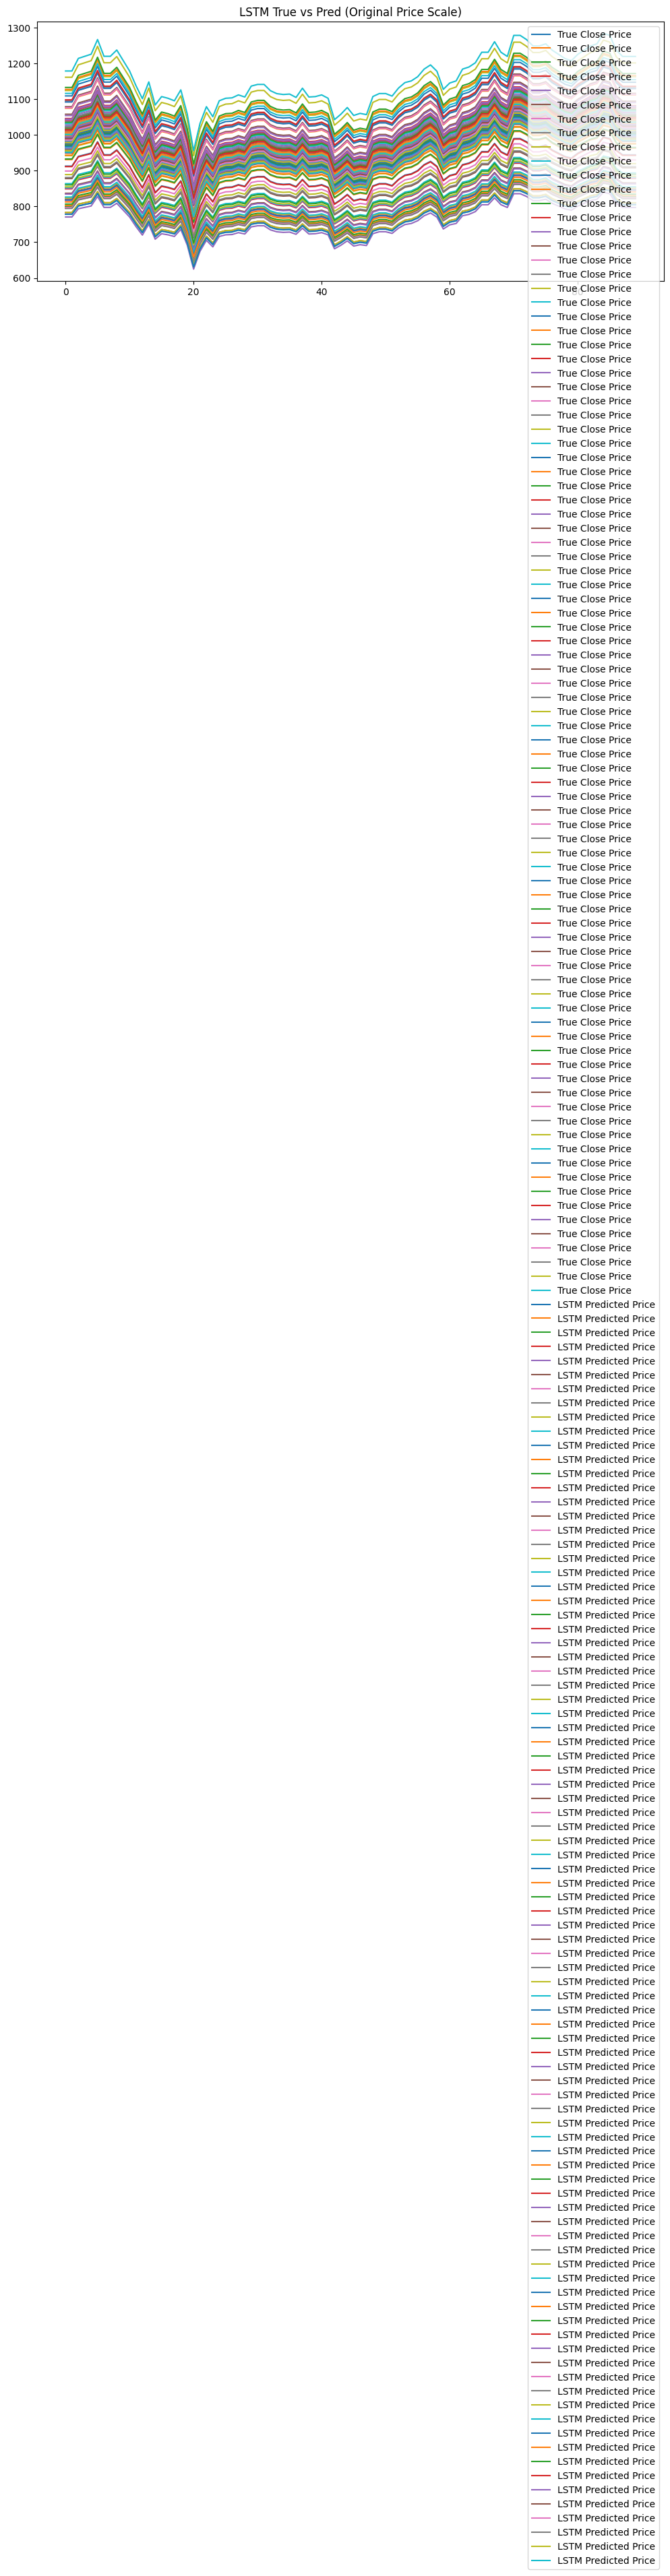

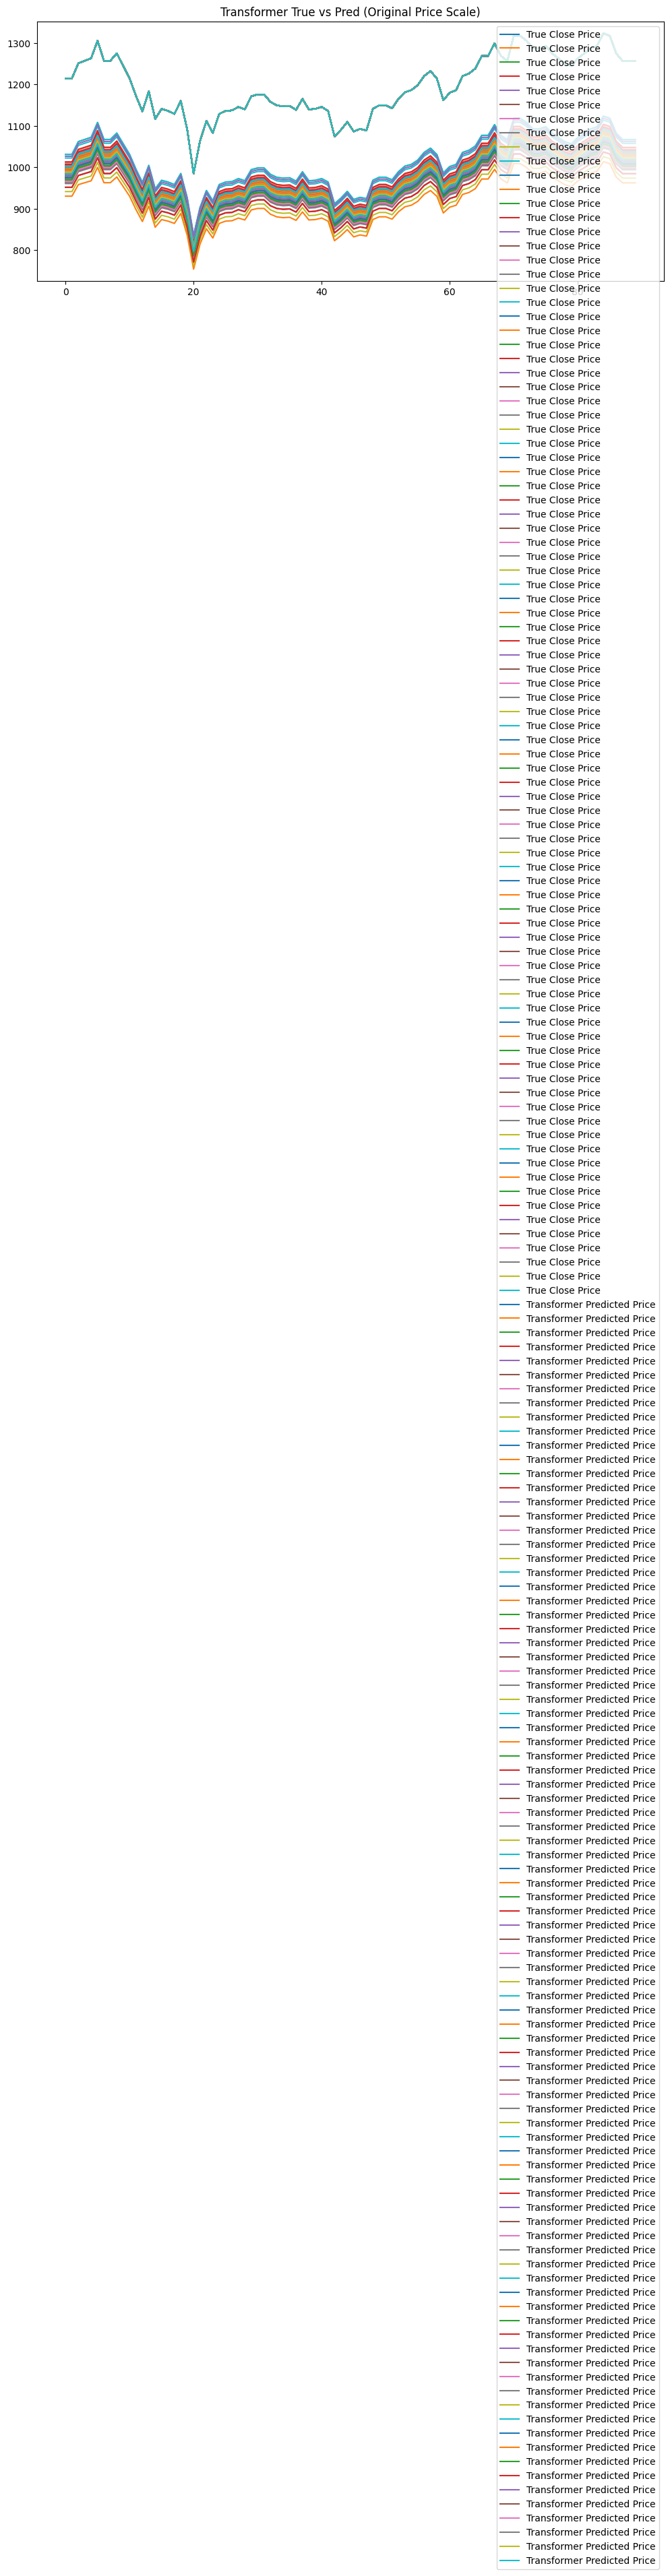

TypeError: Invalid shape (30,) for image data

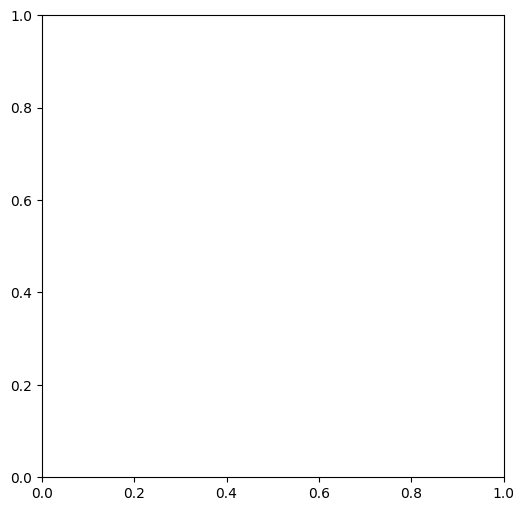

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import math
import random

# 固定隨機種子
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 資料下載與技術指標計算
def download_data(ticker='2330.TW', start='2020-01-01', end='2024-12-31'):
    df = yf.download(ticker, start=start, end=end)
    df['SMA_5'] = df['Close'].rolling(window=5).mean()
    df['SMA_20'] = df['Close'].rolling(window=20).mean()
    delta = df['Close'].diff()
    gain = delta.clip(lower=0)
    loss = -1 * delta.clip(upper=0)
    avg_gain = gain.rolling(window=14).mean()
    avg_loss = loss.rolling(window=14).mean()
    rs = avg_gain / avg_loss
    df['RSI_14'] = 100 - (100 / (1 + rs))
    exp1 = df['Close'].ewm(span=12, adjust=False).mean()
    exp2 = df['Close'].ewm(span=26, adjust=False).mean()
    df['MACD'] = exp1 - exp2
    df['MACD_SIGNAL'] = df['MACD'].ewm(span=9, adjust=False).mean()
    df['MACD_HIST'] = df['MACD'] - df['MACD_SIGNAL']
    df = df.dropna()
    return df

# 製作log return目標(預設)
def prepare_target(df):
    df['logret'] = np.log(df['Close'].shift(-1)) - np.log(df['Close'])
    df = df.dropna()
    return df

# 製作多變量特徵與時間序列切割
class TimeSeriesDataset(Dataset):
    def __init__(self, data, target, lookback=30):
        self.X = data
        self.y = target
        self.lookback = lookback

    def __len__(self):
        return len(self.X) - self.lookback

    def __getitem__(self, idx):
        return (self.X[idx:idx+self.lookback], self.y[idx+self.lookback])

# LSTM模型定義（Baseline）
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.layernorm = nn.LayerNorm(hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.linear = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.layernorm(out[:, -1, :])
        out = self.dropout(out)
        out = self.linear(out)
        return out.squeeze()

# Transformer Positional Encoding
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.pe = pe.unsqueeze(0).to(device)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return x

# Transformer Encoder Block
class TransformerEncoderBlock(nn.Module):
    def __init__(self, d_model, nhead, dim_feedforward=256, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout)
        self.layernorm1 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)

        self.ffn = nn.Sequential(
            nn.Linear(d_model, dim_feedforward),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dim_feedforward, d_model)
        )
        self.layernorm2 = nn.LayerNorm(d_model)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x):
        attn_out, attn_weights = self.attn(x, x, x, need_weights=True)
        x = self.layernorm1(x + self.dropout1(attn_out))
        ffn_out = self.ffn(x)
        x = self.layernorm2(x + self.dropout2(ffn_out))
        return x, attn_weights

# Transformer模型定義（Encoder-only + Mean Pooling）
class TransformerModel(nn.Module):
    def __init__(self, input_dim, d_model=64, nhead=4, num_layers=2, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        self.layers = nn.ModuleList([
            TransformerEncoderBlock(d_model, nhead, dim_feedforward=256, dropout=dropout) for _ in range(num_layers)
        ])
        self.pooling = nn.AdaptiveAvgPool1d(1)
        self.linear = nn.Linear(d_model, 1)

    def forward(self, x):
        # x: (batch, seq_len, input_dim)
        x = self.input_proj(x)  # (batch, seq_len, d_model)
        x = self.pos_encoder(x)
        x = x.transpose(0,1)  # transformer expects seq_len, batch, d_model
        attn_weights_all = []
        for layer in self.layers:
            x, attn_weights = layer(x)
            attn_weights_all.append(attn_weights)
        x = x.transpose(0,1).transpose(1,2)  # batch, d_model, seq_len
        x = self.pooling(x).squeeze(-1)  # batch, d_model
        out = self.linear(x).squeeze(-1)
        return out, attn_weights_all[-1]

# 資料前處理與標準化函式
def data_load_and_process(ticker='2330.TW'):
    df = download_data(ticker)
    df = prepare_target(df)
    features = ['Open', 'High', 'Low', 'Close', 'Volume',
                'SMA_5', 'SMA_20', 'RSI_14', 'MACD', 'MACD_SIGNAL', 'MACD_HIST']
    X = df[features].values
    y = df['logret'].values

    # 時間序切分 8:1:1 (train:val:test)
    n = len(df)
    train_end = int(n*0.8)
    val_end = int(n*0.9)
    X_train, X_val, X_test = X[:train_end], X[train_end:val_end], X[val_end:]
    y_train, y_val, y_test = y[:train_end], y[train_end:val_end], y[val_end:]

    # 標準化(只fit訓練集)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)

    return X_train, y_train, X_val, y_val, X_test, y_test, scaler, df

# 評估指標
def eval_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mse)
    return mse, mae, rmse

# 訓練函式
def train_model(model, train_loader, val_loader, epochs, optimizer, scheduler=None):
    criterion = nn.MSELoss()
    model.to(device)
    best_val_rmse = float('inf')
    val_rmse_history = []

    for epoch in range(epochs):
        model.train()
        train_losses = []
        for xb, yb in train_loader:
            xb, yb = xb.float().to(device), yb.float().to(device)
            optimizer.zero_grad()
            if isinstance(model, TransformerModel):
                pred, _ = model(xb)
            else:
                pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())
        # val
        model.eval()
        val_preds = []
        val_targets = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.float().to(device), yb.float().to(device)
                if isinstance(model, TransformerModel):
                    pred, _ = model(xb)
                else:
                    pred = model(xb)
                val_preds.append(pred.cpu().numpy())
                val_targets.append(yb.cpu().numpy())
        val_preds = np.concatenate(val_preds)
        val_targets = np.concatenate(val_targets)
        _, _, val_rmse = eval_metrics(val_targets, val_preds)
        val_rmse_history.append(val_rmse)
        if scheduler:
            scheduler.step()
        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            best_state = model.state_dict()
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {np.mean(train_losses):.6f}, Val RMSE: {val_rmse:.6f}")
    model.load_state_dict(best_state)
    return model, val_rmse_history

# 預測函式
def predict(model, dataloader):
    model.eval()
    preds = []
    trues = []
    attn_weights_list = []
    with torch.no_grad():
        for xb, yb in dataloader:
            xb = xb.float().to(device)
            if isinstance(model, TransformerModel):
                pred, attn_weights = model(xb)
                attn_weights_list.append(attn_weights.cpu().numpy())
            else:
                pred = model(xb)
            preds.append(pred.cpu().numpy())
            trues.append(yb.numpy())
    preds = np.concatenate(preds)
    trues = np.concatenate(trues)
    return preds, trues, attn_weights_list if attn_weights_list else None

# 主程式執行
def main():
    lookback = 30
    batch_size = 64
    epochs = 30

    # 讀資料與前處理
    X_train, y_train, X_val, y_val, X_test, y_test, scaler, df = data_load_and_process()

    # 製作Dataset + DataLoader
    train_dataset = TimeSeriesDataset(X_train, y_train, lookback)
    val_dataset = TimeSeriesDataset(X_val, y_val, lookback)
    test_dataset = TimeSeriesDataset(X_test, y_test, lookback)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    input_dim = X_train.shape[1]

    # LSTM 模型訓練
    lstm_model = LSTMModel(input_dim).to(device)
    lstm_optimizer = optim.Adam(lstm_model.parameters(), lr=1e-4)
    lstm_model, lstm_val_history = train_model(lstm_model, train_loader, val_loader, epochs, lstm_optimizer)

    # Transformer 模型訓練（含Warmup與CosineAnnealingWarmRestarts）
    transformer_model = TransformerModel(input_dim).to(device)
    transformer_optimizer = optim.AdamW(transformer_model.parameters(), lr=3e-4, weight_decay=1e-4)
    # 簡單warmup scheduler函式
    def warmup_cosine_anneal(step, warmup_steps=3*len(train_loader)):
        if step < warmup_steps:
            return step / warmup_steps
        else:
            progress = (step - warmup_steps) / (epochs*len(train_loader) - warmup_steps)
            return 0.5 * (1 + math.cos(progress * math.pi * 2 * 3))

    class LambdaLRWarmup:
        def __init__(self, optimizer, lr_lambda):
            self.optimizer = optimizer
            self.lr_lambda = lr_lambda
            self.step_num = 0
        def step(self):
            self.step_num += 1
            lr = self.lr_lambda(self.step_num)
            for param_group in self.optimizer.param_groups:
                param_group['lr'] = lr

    lr_scheduler = LambdaLRWarmup(transformer_optimizer, warmup_cosine_anneal)

    transformer_model.train()
    criterion = nn.MSELoss()
    best_val_rmse = float('inf')
    best_state = None
    val_rmse_history = []
    for epoch in range(epochs):
        transformer_model.train()
        train_losses = []
        for xb, yb in train_loader:
            xb, yb = xb.float().to(device), yb.float().to(device)
            transformer_optimizer.zero_grad()
            pred, _ = transformer_model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            transformer_optimizer.step()
            lr_scheduler.step()
            train_losses.append(loss.item())
        # val
        transformer_model.eval()
        val_preds = []
        val_targets = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.float().to(device), yb.float().to(device)
                pred, _ = transformer_model(xb)
                val_preds.append(pred.cpu().numpy())
                val_targets.append(yb.cpu().numpy())
        val_preds = np.concatenate(val_preds)
        val_targets = np.concatenate(val_targets)
        _, _, val_rmse = eval_metrics(val_targets, val_preds)
        val_rmse_history.append(val_rmse)
        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            best_state = transformer_model.state_dict()
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {np.mean(train_losses):.6f}, Val RMSE: {val_rmse:.6f}")
    transformer_model.load_state_dict(best_state)

    # 測試階段評估
    lstm_preds, lstm_trues, _ = predict(lstm_model, test_loader)
    trans_preds, trans_trues, trans_attn = predict(transformer_model, test_loader)

    # 反轉標準化logret為股價預測（Close價格的log return反轉）
    base_price = df['Close'].values[-len(trans_trues)-lookback:-lookback]

    def inv_logret(base_price, logret_pred):
        price_pred = base_price * np.exp(logret_pred)
        return price_pred

    lstm_price_pred = inv_logret(base_price, lstm_preds)
    trans_price_pred = inv_logret(base_price, trans_preds)
    true_price = base_price * np.exp(lstm_trues)

    # 計算指標（標準化空間與原始價格空間）
    print("LSTM 評估指標（標準化空間）:", eval_metrics(lstm_trues, lstm_preds))
    print("Transformer 評估指標（標準化空間）:", eval_metrics(trans_trues, trans_preds))
    print("LSTM 評估指標（原始價格尺度）:", eval_metrics(true_price, lstm_price_pred))
    print("Transformer 評估指標（原始價格尺度）:", eval_metrics(true_price, trans_price_pred))

    # 繪圖：True vs Pred（原始價格尺度）
    plt.figure(figsize=(12, 5))
    plt.plot(true_price, label='True Close Price')
    plt.plot(lstm_price_pred, label='LSTM Predicted Price')
    plt.title('LSTM True vs Pred (Original Price Scale)')
    plt.legend()
    plt.show()

    plt.figure(figsize=(12, 5))
    plt.plot(true_price, label='True Close Price')
    plt.plot(trans_price_pred, label='Transformer Predicted Price')
    plt.title('Transformer True vs Pred (Original Price Scale)')
    plt.legend()
    plt.show()

    # 繪製Transformer最後一層Attention heatmap（取第一批第一筆資料）
    attn_weights = trans_attn[0]  # shape: (batch, heads, seq_len, seq_len)
    attn_weights = attn_weights[0]  # 第一筆(batch=0), shape (heads, seq_len, seq_len)
    avg_attn = attn_weights.mean(axis=0)  # 多頭平均，shape (seq_len, seq_len)
    plt.figure(figsize=(8, 6))
    plt.imshow(avg_attn, cmap='viridis')
    plt.colorbar()
    plt.title('Transformer Attention Heatmap (Average over Heads)')
    plt.xlabel('Time Steps')
    plt.ylabel('Time Steps')
    plt.show()

    # 驗證集學習曲線（epoch vs val RMSE）
    plt.figure(figsize=(8,5))
    plt.plot(lstm_val_history, label='LSTM Validation RMSE')
    plt.plot(val_rmse_history, label='Transformer Validation RMSE')
    plt.title('Validation RMSE curve')
    plt.xlabel('Epoch')
    plt.ylabel('RMSE')
    plt.legend()
    plt.show()

if __name__ == "__main__":
    main()
